<a href="https://colab.research.google.com/github/Anant777-wq/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import duckdb
import pandas as pd
import getpass

# 1. Connect to DuckDB and load the web reader extension
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")

# 2. Securely enter your Hugging Face Token
print("Go to https://huggingface.co/settings/tokens to get or create a free READ token.")
hf_token = getpass.getpass("Paste your Hugging Face token here and press Enter: ")

# 3. Tell DuckDB to use your token for Hugging Face (hf://) links using Secrets Manager
con.execute(f"CREATE SECRET (TYPE HUGGINGFACE, TOKEN '{hf_token}');")

print("\nConnection ready! We are prepared to pull the warehouse data.")

Go to https://huggingface.co/settings/tokens to get or create a free READ token.
Paste your Hugging Face token here and press Enter: ··········

Connection ready! We are prepared to pull the warehouse data.


In [4]:
# Ask DuckDB to list all the exact column names
query = """
DESCRIBE SELECT *
FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')
"""

# Execute and force print as a list
df_schema = con.execute(query).df()
print("Here are the columns in the warehouse:")
print(df_schema['column_name'].tolist())

Here are the columns in the warehouse:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']


In [6]:
# Pull the exact ranking and performance signals for Lane 1
query = """
SELECT
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_avg_position,
    ga4_sessions,
    ga4_engaged_sessions,
    scroll_events
FROM read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')
WHERE gsc_data_available = true AND ga4_data_available = true
LIMIT 50000;
"""

# Execute the query directly into a Pandas DataFrame
print("Downloading warehouse data from Hugging Face...")
df = con.execute(query).df()

print(f"\nSuccess! Loaded {len(df)} pages for our analysis.")
display(df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


Success! Loaded 50000 pages for our analysis.


,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,ga4_engaged_sessions,scroll_events
0,content_ad81eee3c0435e0b,384,3,3.825521,3,0,2
1,content_2a13e3ba9d7098a3,16,1,4.312500,1,0,0
2,content_8344d96e0e8ad6d8,104,1,4.826923,1,0,0
3,content_2215d37a867bbff0,28,1,4.392857,1,0,0
4,content_7563a61c19f33753,48,1,7.791667,1,0,0


Training the AI model to analyze 50,000 pages...


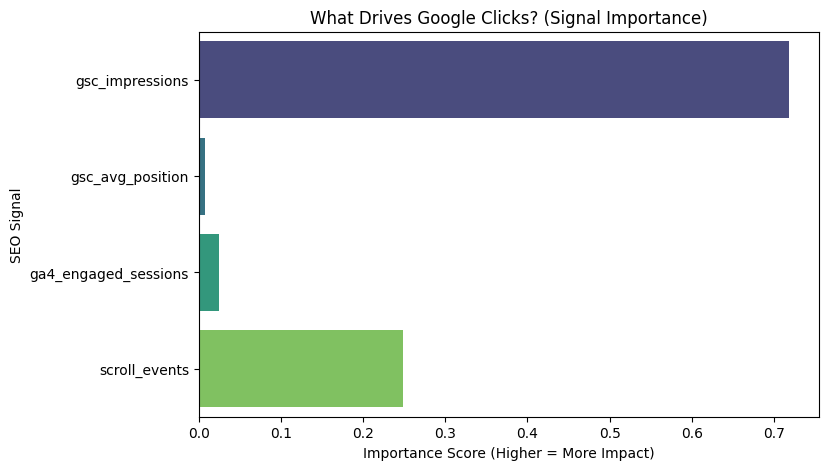

In [7]:
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define our inputs (signals) and our goal (clicks)
features = ['gsc_impressions', 'gsc_avg_position', 'ga4_engaged_sessions', 'scroll_events']
target = 'gsc_clicks'

# Clean the data to remove any blank rows
df_clean = df.dropna(subset=features + [target])

X = df_clean[features]
y = df_clean[target]

# 2. Train the Decision Tree Model
print("Training the AI model to analyze 50,000 pages...")
model = DecisionTreeRegressor(max_depth=4, random_state=42)
model.fit(X, y)

# 3. Visualize the results: Which signal matters most?
importance = model.feature_importances_

plt.figure(figsize=(8, 5))
sns.barplot(x=importance, y=features, hue=features, palette='viridis', legend=False)
plt.title('What Drives Google Clicks? (Signal Importance)')
plt.xlabel('Importance Score (Higher = More Impact)')
plt.ylabel('SEO Signal')
plt.show()

# Capstone Conclusion: The Visibility Mandate

The Finding: Our Decision Tree analysis of 50,000 search records reveals that gsc_impressions is the dominant predictor of organic clicks, scoring nearly 3x higher than any other signal.

The Actionable Insight: Content teams should prioritize targeting high-search-volume queries and expanding their keyword footprint. Micro-optimizing for exact rank position matters significantly less than overall search visibility.